# Evaluating Your Short-Position Algorithm

Recall that you backtested your short-position DMAC trading algorithm in the previous activity. Now, you’ll use the backtesting data to evaluate the risk/reward characteristics of both the trading algorithm portfolio and the per-trade behavior.


## Instructions:

When you calculate the profit/loss value for each trade, remember that the difference in the case of a short-position strategy is the inverse of that for a long-position strategy. That is, you calculate the profit/loss by using the value of the entry portfolio holding minus value of the exit portfolio holding.

Note that the starter notebook file already includes the algorithm and the backtesting steps that you completed in earlier activities. For this activity, proceed straight to the evaluation section of the notebook file, and then complete the following steps:

1. Review the provided code. This includes the `import` statements for the required libraries, the creation of the Pandas DataFrame from the `vnq.csv` file in the `Resources` folder, the code that creates and visualizes the algorithm, and the code that backtests your short-position DMAC strategy.

2. Initialize a portfolio evaluation DataFrame with an index set to `['Annualized Return', 'Cumulative Returns', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio']` and the columns set to `['Backtest']`.

3. Calculate and assign the following portfolio evaluation metrics to the portfolio evaluation DataFrame:

    * Annualized return

    * Cumulative returns

    * Annual volatility

    * Sharpe ratio

    * Sortino ratio

4. Review the portfolio evaluation metrics, and then answer the following question: Would you advise a risk-averse investor to invest in a portfolio that uses this algorithm?

5. Initialize a trade evaluation DataFrame with the columns set to `['Stock', 'Entry Date', 'Exit Date', 'Shares', 'Entry Share Price', 'Exit Share Price', 'Entry Portfolio Holding', 'Exit Portfolio Holding', 'Profit/Loss']`.

6. Create the `for` loop to iterate through the backtested signals DataFrame, pulling the relevant entry and exit data values to calculate the per-trade profit/loss values and appending each record to the trade evaluation DataFrame.

7. Answer the following question: Based on the trade evaluation metrics, has your opinion changed regarding the advisability of this portfolio for a risk-averse investor?


## Step 1: Review the provided code. This includes the `import` statements for the required libraries, the creation of the Pandas DataFrame from the `vnq.csv` file in the `Resources` folder, the code that creates and visualizes the algorithm, and the code that backtests your short-position DMAC strategy.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### Read the CSV file into Pandas DataFrame

In [2]:
# Read the vnq.csv file located in the Resources folder into a Pandas DataFrame
# Set the Date column as the DateTimeIndex
vnq_df = pd.read_csv(
    Path("14.1/02-Create_a_Short_Position_Algorithm/Resources/vnq.csv"),
    index_col="Date",
    parse_dates=True
)

# Review the DataFrame
vnq_df.head()

/var/folders/s9/ml6qrgdx03zdn76qyj8422mh0000gn/T/ipykernel_1902/4018939441.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  vnq_df = pd.read_csv(


,Open,High,Low,Close,Volume
Date,,,,,
2007-01-03,77.339996,77.709999,76.400002,44.707417,525700
2007-01-04,77.230003,77.260002,76.629997,44.765377,166100
2007-01-05,77.099998,77.099998,75.750000,43.936401,143700
2007-01-08,76.000000,76.000000,75.430000,44.000164,87000
2007-01-09,75.730003,76.959999,75.730003,44.556675,136300


### Generate a Dual Moving Average Crossover Trading Signal

In [3]:
# Filter the date index and close columns
signals_df = vnq_df.loc[:,['Close']]

# Set the short window and long window
short_window = 50
long_window = 100

# Generate the short and long moving averages (50 and 100 days, respectively)
signals_df['SMA50'] = signals_df['Close'].rolling(window=short_window).mean()
signals_df['SMA100'] = signals_df['Close'].rolling(window=long_window).mean()
signals_df['Signal'] = 0.0

signals_df.tail()

,Close,SMA50,SMA100,Signal
Date,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0
2009-12-28,31.517859,28.504734,27.645874,0.0
2009-12-29,31.046522,28.575901,27.702575,0.0
2009-12-30,31.094339,28.636155,27.745596,0.0
2009-12-31,30.561541,28.696138,27.789032,0.0


In [4]:
# Generate the trading signal 0 or 1,
# where 1 is when the SMA50 is less than than the SMA100
# where 0 is when the SMA50 is greater than the SMA100
signals_df.iloc[short_window: , 3] = np.where(
    signals_df['SMA50'][short_window: ] < signals_df['SMA100'][short_window: ],1.0,0.0
)

# Calculate the points in time at which a position should be taken, 1 or -1
signals_df['Entry/Exit'] = signals_df['Signal'].diff()

# Review the DataFrame
signals_df.tail(10)

,Close,SMA50,SMA100,Signal,Entry/Exit
Date,,,,,
2009-12-17,29.639492,28.167839,27.217638,0.0,0.0
2009-12-18,29.835062,28.211270,27.294345,0.0,0.0
2009-12-21,30.239697,28.258072,27.367152,0.0,0.0
2009-12-22,30.556675,28.312024,27.443329,0.0,0.0
2009-12-23,30.920845,28.381082,27.519007,0.0,0.0
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0


### Plot Entry and Exit Points of Dual Moving Average Crossover Trading Strategy

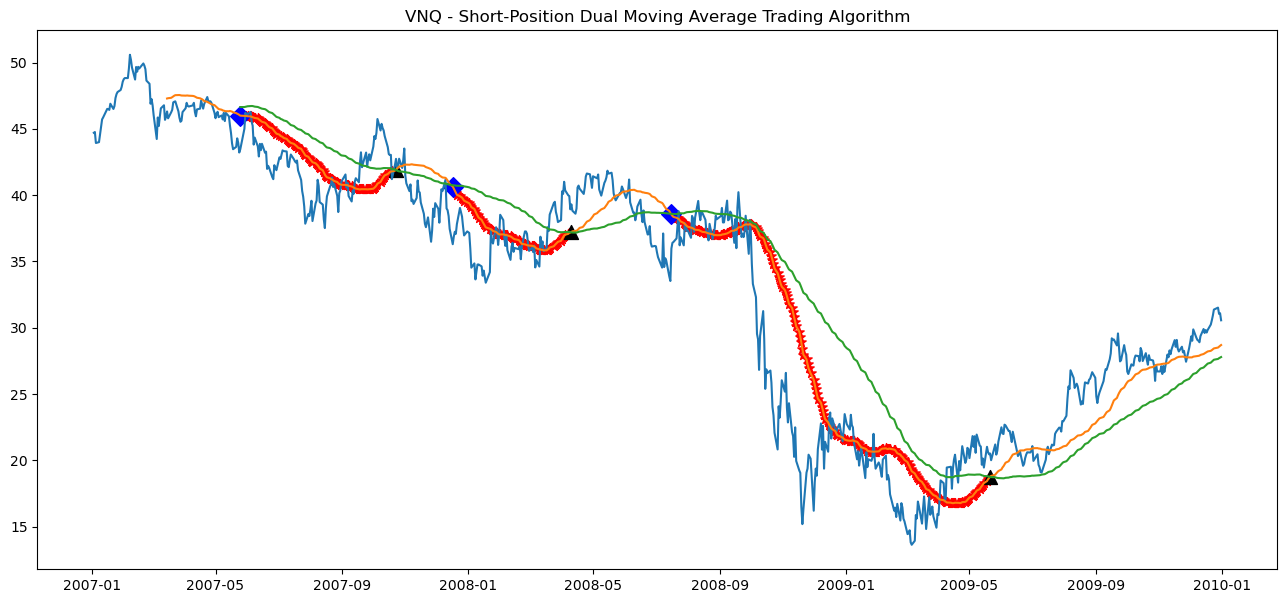

In [10]:
x = signals_df.index
plt.figure(figsize=(16,7))
plt.title("VNQ - Short-Position Dual Moving Average Trading Algorithm")
plt.plot(x,signals_df[['Close','SMA50','SMA100']],label= ['Close','SMA50','SMA100'])
plt.scatter(signals_df[signals_df['Signal'] == 1.0].index, signals_df[signals_df['Signal'] == 1.0]['SMA50'],color='red',marker='*',s=50)
plt.scatter(signals_df[signals_df['Entry/Exit'] == 1.0].index, signals_df[signals_df['Entry/Exit'] == 1.0]['SMA50'],color='blue',marker='D',s=100)
plt.scatter(signals_df[signals_df['Entry/Exit'] == -1.0].index, signals_df[signals_df['Entry/Exit'] == -1.0]['SMA50'],color='black',marker='^',s=100)


plt.show()

### Backtest the Trading Strategy

In [5]:
# Set the initial capital
initial_capital = float(100000)

# Set the share size
share_size = -500

# Take a 500 share position where the dual moving average crossover is 1 (SMA50 is greater than SMA100)
signals_df["Position"] = share_size * signals_df["Signal"]

# Find the points in time where a 500 share position is bought or sold
signals_df["Entry/Exit Position"] = signals_df["Position"].diff()

# Multiply share price by entry/exit positions and get the cumulatively sum
signals_df["Portfolio Holdings"] = (
    signals_df["Close"] * signals_df["Entry/Exit Position"].cumsum()
)

# Subtract the initial capital by the portfolio holdings to get the amount of liquid cash in the portfolio
signals_df["Portfolio Cash"] = (
    initial_capital - (signals_df["Close"] * signals_df["Entry/Exit Position"]).cumsum()
)

# Get the total portfolio value by adding the cash amount by the portfolio holdings (or investments)
signals_df["Portfolio Total"] = (
    signals_df["Portfolio Cash"] + signals_df["Portfolio Holdings"]
)

# Calculate the portfolio daily returns
signals_df["Portfolio Daily Returns"] = signals_df["Portfolio Total"].pct_change()

# Calculate the cumulative returns
signals_df["Portfolio Cumulative Returns"] = (
    1 + signals_df["Portfolio Daily Returns"]
).cumprod() - 1

signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position,Entry/Exit Position,Portfolio Holdings,Portfolio Cash,Portfolio Total,Portfolio Daily Returns,Portfolio Cumulative Returns
Date,,,,,,,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0,0.0,0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0,0.0,0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0,0.0,0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0,0.0,0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0,0.0,0.0,106587.2295,106587.2295,0.0,0.065872


### Plot Entry/Exit Points of Backtest Results

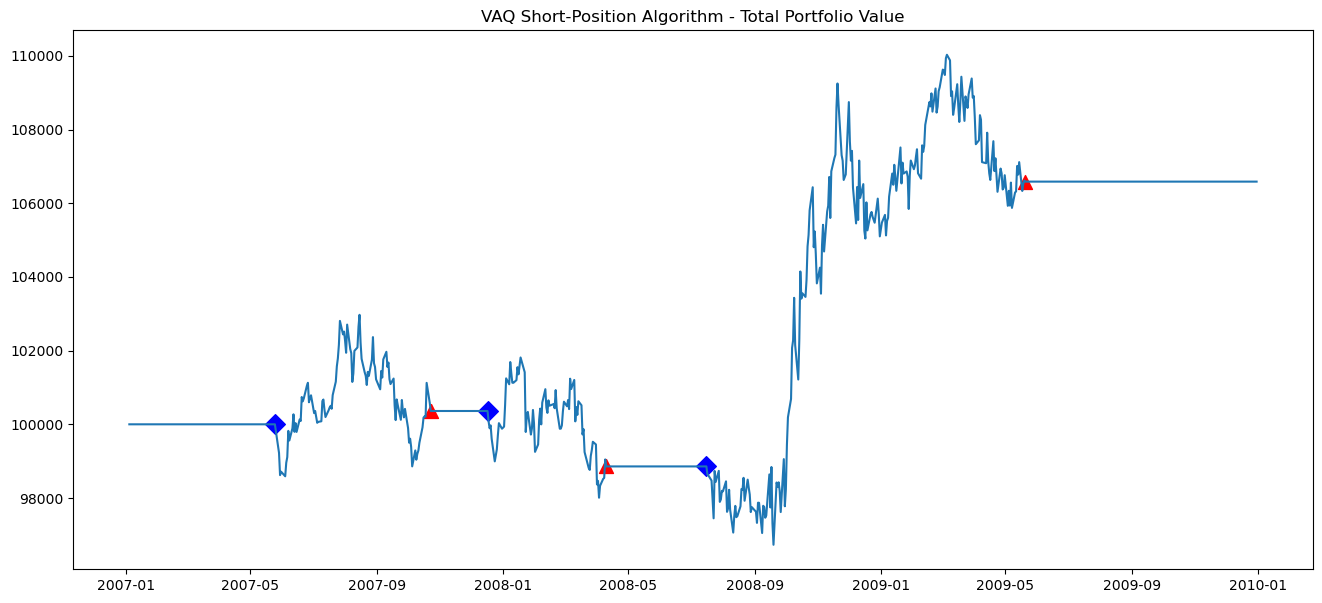

In [21]:
# Visualize the entry positions relative to the Portfolio Total
x = signals_df.index

plt.figure(figsize=(16,7))
plt.title('VAQ Short-Position Algorithm - Total Portfolio Value')
plt.plot(signals_df[["Portfolio Total"]])
plt.scatter(signals_df[signals_df['Entry/Exit'] == 1.0].index, signals_df[signals_df['Entry/Exit'] == 1.0]["Portfolio Total"],color='blue',marker='D',s=100)
plt.scatter(signals_df[signals_df['Entry/Exit'] == -1.0].index, signals_df[signals_df['Entry/Exit'] == -1.0]["Portfolio Total"],color='red',marker='^',s=100)

plt.show()

## Step 2: Initialize a portfolio evaluation DataFrame with an index set to `['Annualized Return', 'Cumulative Returns', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio']` and the columns set to `['Backtest']`.

### Prepare Portfolio Evaluation Metrics DataFrame

In [6]:
# Create the list of the metric names
metrics = [
    'Annualized Return',
    'Cumulative Returns',
    'Annual Volatility',
    'Sharpe Ratio',
    'Sortino Ratio'
]

# Create a list that holds the column name
columns = ['Backtest']

# Initialize the DataFrame with index set to evaluation metrics and columns 
portfolio_evaluation_df = pd.DataFrame(index=metrics, columns=columns)

# Review the DataFrame
portfolio_evaluation_df

,Backtest
Annualized Return,NaN
Cumulative Returns,NaN
Annual Volatility,NaN
Sharpe Ratio,NaN
Sortino Ratio,NaN


## Step 3: Calculate and assign the following portfolio evaluation metrics to the portfolio evaluation DataFrame:

    * Annualized return

    * Cumulative returns

    * Annual volatility

    * Sharpe ratio

    * Sortino ratio


In [7]:
# Calculate the Annualized return metric
portfolio_evaluation_df.loc['Annualized Return'] = (
    signals_df['Portfolio Daily Returns'].mean() * 252
)

In [8]:
# Calculate the Cumulative returns metric
portfolio_evaluation_df.loc['Cumulative Returns'] = signals_df['Portfolio Cumulative Returns'].iloc[-1]


In [9]:
# Calculate the Annual volatility metric
portfolio_evaluation_df.loc['Annual Volatility'] = signals_df['Portfolio Daily Returns'].std() * np.sqrt(252)

In [10]:
# Calculate the Sharpe ratio
portfolio_evaluation_df.loc['Sharpe Ratio'] = (
    signals_df['Portfolio Daily Returns'].mean() * 252) / (
    signals_df['Portfolio Daily Returns'].std() * np.sqrt(252)

)

In [18]:
# Calculate the Sortino ratio
# Start by calculating the downside return values

# Create a DataFrame that contains the Portfolio Daily Returns column
sortino_ratio_df = signals_df[['Portfolio Daily Returns']]

# Create a column to hold downside return values
sortino_ratio_df.loc[:,'Downside Returns'] = 0.0

sortino_ratio_df.head()
sortino_ratio_df.tail()

,Portfolio Daily Returns,Downside Returns
Date,,
2009-12-24,0.0,0.0
2009-12-28,0.0,0.0
2009-12-29,0.0,0.0
2009-12-30,0.0,0.0
2009-12-31,0.0,0.0


In [19]:
# Find Portfolio Daily Returns values less than 0, 
# square those values, and add them to the Downside Returns column
sortino_ratio_df.loc[sortino_ratio_df['Portfolio Daily Returns'] < 0, 'Downside Returns'] = sortino_ratio_df['Portfolio Daily Returns']**2

sortino_ratio_df.tail()

,Portfolio Daily Returns,Downside Returns
Date,,
2009-12-24,0.0,0.0
2009-12-28,0.0,0.0
2009-12-29,0.0,0.0
2009-12-30,0.0,0.0
2009-12-31,0.0,0.0


In [20]:
# Calculate the annualized return value
annualized_return = sortino_ratio_df['Portfolio Daily Returns'].mean() * 252

annualized_return

np.float64(0.02333809244172052)

In [21]:
# Calculate the annualized downside standard deviation value
downside_standard_deviation = np.sqrt(sortino_ratio_df['Downside Returns'].mean()) * np.sqrt(252)

downside_standard_deviation

np.float64(0.04338856971987877)

In [22]:
# Divide the annualized return value by the downside standard deviation value
sortino_ratio = annualized_return / downside_standard_deviation

portfolio_evaluation_df.loc['Sortino Ratio'] = sortino_ratio

In [23]:
portfolio_evaluation_df

,Backtest
Annualized Return,0.023338
Cumulative Returns,0.065872
Annual Volatility,0.063566
Sharpe Ratio,0.36715
Sortino Ratio,0.537886


## Step 4: Answer the following question

**Question:** Would you advise a risk-averse investor to invest in a portfolio that uses this algorithm?

**Answer:** First, a risk-averse investor is unlikely to invest in a short-position strategy. Generally, the markets trend higher and taking a short position is counter to that thinking. That said, the metrics associated with annual volatility are relatively small at 0.0635. The downside volatility, or Sortino Ratio, is quite high at 0.53, but this is a strategy where that works is our favor. Given the information depicted in the portfolio evaluation DataFrame, and given the right market conditions, it would make sense for a risk-averse investor to make a small allocation to this trading strategy. 


## Step 5: Initialize a trade evaluation DataFrame with the columns set to `['Stock', 'Entry Date', 'Exit Date', 'Shares', 'Entry Share Price', 'Exit Share Price', 'Entry Portfolio Holding', 'Exit Portfolio Holding', 'Profit/Loss']`.

In [24]:
# Initialize the trade evaluation DataFrame
trade_evaluation_df = pd.DataFrame(
    columns=[
        'Stock', 
        'Entry Date', 
        'Exit Date', 
        'Shares', 
        'Entry Share Price', 
        'Exit Share Price', 
        'Entry Portfolio Holding', 
        'Exit Portfolio Holding', 
        'Profit/Loss']
)

trade_evaluation_df

,Stock,Entry Date,Exit Date,Shares,Entry Share Price,Exit Share Price,Entry Portfolio Holding,Exit Portfolio Holding,Profit/Loss


## Step 6: Create the `for` loop to iterate through the backtested signals DataFrame, pulling the relevant entry and exit data values to calculate the per-trade profit/loss values and appending each record to the trade evaluation DataFrame.

In [32]:
# Initialize the iterative variables
entry_date = ""
exit_date = ""
entry_portfolio_holding = 0.0
exit_portfolio_holding = 0.0
share_size = 0
entry_share_price = 0.0
exit_share_price = 0.0

# Loop through the signal DataFrame
# If `Entry/Exit` is 1, set entry trade metrics
# Else if `Entry/Exit` is -1, set exit trade metrics and calculate profit,
# Then append the record to the trade evaluation DataFrame
for index, row in signals_df.iterrows():
    if row['Entry/Exit'] == 1:
        entry_date = index
        entry_portfolio_holding = abs(row['Portfolio Holdings'])
        share_size = row['Entry/Exit Position']
        entry_share_price = row['Close']

    elif row['Entry/Exit'] == -1:
        exit_date = index
        exit_portfolio_holding = abs(row['Close'] * row['Entry/Exit Position'])
        exit_share_price = row['Close']
        profit_loss =  entry_portfolio_holding - exit_portfolio_holding
        
        new_df = pd.DataFrame([{
                'Stock': 'AAPL',
                'Entry Date': entry_date,
                'Exit Date': exit_date,
                'Shares': share_size,
                'Entry Share Price': entry_share_price,
                'Exit Share Price': exit_share_price,
                'Entry Portfolio Holding': entry_portfolio_holding,
                'Exit Portfolio Holding': exit_portfolio_holding,
                'Profit/Loss': profit_loss
            }])
        
        trade_evaluation_df = pd.concat([trade_evaluation_df, new_df], ignore_index = True)
        
        
#         trade_evaluation_df = trade_evaluation_df.append(
#             {
#                 'Stock': 'AAPL',
#                 'Entry Date': entry_date,
#                 'Exit Date': exit_date,
#                 'Shares': share_size,
#                 'Entry Share Price': entry_share_price,
#                 'Exit Share Price': exit_share_price,
#                 'Entry Portfolio Holding': entry_portfolio_holding,
#                 'Exit Portfolio Holding': exit_portfolio_holding,
#                 'Profit/Loss': profit_loss
#             },
#             ignore_index=True)

# Review the DataFrame
trade_evaluation_df

,Stock,Entry Date,Exit Date,Shares,Entry Share Price,Exit Share Price,Entry Portfolio Holding,Exit Portfolio Holding,Profit/Loss
0,AAPL,2007-05-25 00:00:00,2007-10-23 00:00:00,-500.0,43.461689,42.738773,21730.8445,21369.3865,361.458
1,AAPL,2007-12-17 00:00:00,2008-04-10 00:00:00,-500.0,36.302608,39.311516,18151.304,19655.758,-1504.454
2,AAPL,2008-07-16 00:00:00,2009-05-21 00:00:00,-500.0,35.972519,20.512068,17986.2595,10256.034,7730.2255


In [31]:
new_df = pd.DataFrame([{
                'Stock': 'AAPL',
                'Entry Date': entry_date,
                'Exit Date': exit_date,
                'Shares': share_size,
                'Entry Share Price': entry_share_price,
                'Exit Share Price': exit_share_price,
                'Entry Portfolio Holding': entry_portfolio_holding,
                'Exit Portfolio Holding': exit_portfolio_holding,
                'Profit/Loss': profit_loss
            }])
new_df

,Stock,Entry Date,Exit Date,Shares,Entry Share Price,Exit Share Price,Entry Portfolio Holding,Exit Portfolio Holding,Profit/Loss
0,AAPL,2007-05-25,2007-10-23,-500.0,43.461689,42.738773,21730.8445,21369.3865,361.458


## Step 7: Answer the following question:

**Question:** Based on the trade evaluation metrics, has your opinion changed regarding the advisability of this portfolio for a risk-averse investor?

**Answer:** Based on the trade evaluation metrics, this trading algorithm strategy produced mixed results. The first trade returned a small gain, but the second trade ended in a sizable loss of funds. However,in a down market, where short-position strategies are best implemented, the strategy performed well returning over 7700 dollars. Given the correct market conditions, I would suggest that the risk-averse investor make a small investment in this strategy, if only to add some downside protection to their portfolio. 